# LIM-CS blocked out-of-sample skill

This script/notebook performs:
1. Consecutive leave-3-year-block-out LIM fitting and forecasting.
2. Centered 3-month running-mean PP skill calculation.
3. Region-by-lead heatmap and regional line panels.
4. Map of the latest out-of-sample lead with r >= 0.5.

The final remainder block is retained; for 1998-2025 this is 2025 alone.
The LIM operator is refitted in every fold. The state-vector preprocessing is
inherited from the full-record LIM file and is not recomputed within each fold.

In [1]:
# ============================================================
# 0. Imports and settings
# ============================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import date
from matplotlib.colors import BoundaryNorm, ListedColormap


LIM_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/"
    "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_"
    "PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc"
)

OUT_DIR = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

CV_SKILL_FILE = OUT_DIR / (
    "Cyclostationary_LIM_PP_forecast_skill_24month_"
    "3month_running_mean_leave3yearblockout_"
    "corr_threshold05_RECCAP2_all_regions_valid_zero30.nc"
)

VALID_MASK_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/"
    "GlobColour_PP_grid_validity_RECCAP2_all_regions/"
    "valid_mask_zero30/"
    "RECCAP2_all_regions_valid_mask_zero30_on_PPgrid.nc"
)

BLOCK_YEARS = 3
MAX_LEAD = 24
INTERNAL_MAX_LEAD = MAX_LEAD + 1
THRESHOLD = 0.5
TARGET_STATE = "PP"
RIDGE_ALPHA = 1.0e-3
MIN_SAMPLES = 12

# Recommended strict rule: initialization and the complete centered
# target window must stay in the same held-out block.
STRICT_WITHIN_VALIDATION_BLOCK = True

EXCLUDE_REGIONS = [6, 18, 19, 29]
SAVE_FIGURES = False

CENTRAL_LONGITUDE = 210
PLOT_STRIDE = 4
DISPLAY_MAX_LEAD = 15

FIG_HEATMAP = OUT_DIR / (
    "LIM_CS_PP_leave3yearblockout_3month_running_mean_"
    "pooled_skill_heatmap.png"
)
FIG_LINES = OUT_DIR / (
    "LIM_CS_PP_leave3yearblockout_3month_running_mean_"
    "regional_skill_lines.png"
)
MAP_FIG = OUT_DIR / (
    "Map_latest_PP_skillful_lead_leave3yearblockout_"
    "3month_running_mean_corr_ge_05_"
    "RECCAP2_all_regions_valid_zero30_"
    "excluding_R6_R18_R19_R29.png"
)

BASIN_SHORT = {
    "Pacific Ocean": "PO",
    "Indian Ocean": "IO",
    "Atlantic Ocean": "AO",
    "Southern Ocean": "SO",
    "Arctic Ocean": "ArO",
}

BASIN_ORDER = [
    "Pacific Ocean",
    "Indian Ocean",
    "Atlantic Ocean",
    "Southern Ocean",
    "Arctic Ocean",
]

In [2]:
# ============================================================
# 1. Helpers
# ============================================================

def decode_strings(values):
    return np.asarray([
        v.decode("utf-8") if isinstance(v, bytes) else str(v)
        for v in values
    ], dtype=object)


def decode_str(v):
    if isinstance(v, bytes):
        return v.decode("utf-8")
    arr = np.asarray(v)
    if arr.shape == ():
        item = arr.item()
        return item.decode("utf-8") if isinstance(item, bytes) else str(item)
    return str(v)


def corr_1d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 3:
        return np.nan
    a = a[ok]
    b = b[ok]
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def latest_skill_month(skill, threshold=0.5):
    skill = np.asarray(skill, dtype=float)
    good = np.where(np.isfinite(skill) & (skill >= threshold))[0]
    return 0 if good.size == 0 else int(good.max() + 1)


def build_year_blocks(times, block_years=3):
    years = pd.DatetimeIndex(pd.to_datetime(times)).year.values
    unique_years = np.unique(years)
    blocks = []
    for i0 in range(0, len(unique_years), block_years):
        fold_years = unique_years[i0:i0 + block_years]
        blocks.append({
            "fold": len(blocks),
            "years": fold_years.astype(np.int16),
            "start_year": int(fold_years[0]),
            "end_year": int(fold_years[-1]),
            "validation_mask": np.isin(years, fold_years),
        })
    return blocks


def fit_cyclostationary_lim_one_region(
    X,
    months,
    training_time_mask,
    ridge_alpha=1.0e-3,
    min_samples=12,
):
    """Fit monthly G using transitions whose two endpoints are training months."""
    X = np.asarray(X, dtype=np.float64)
    months = np.asarray(months, dtype=np.int16)
    training_time_mask = np.asarray(training_time_mask, dtype=bool)

    n_time, n_state = X.shape
    if training_time_mask.shape != (n_time,):
        raise ValueError("training_time_mask must have shape (time,)")

    G = np.full((12, n_state, n_state), np.nan, dtype=np.float64)
    fit_mean_x = np.full((12, n_state), np.nan, dtype=np.float64)
    fit_mean_y = np.full((12, n_state), np.nan, dtype=np.float64)
    n_samples = np.zeros(12, dtype=np.int16)

    train_transition = training_time_mask[:-1] & training_time_mask[1:]

    for month in range(1, 13):
        idx = np.where((months[:-1] == month) & train_transition)[0]
        X0 = X[idx]
        X1 = X[idx + 1]

        good = np.isfinite(X0).all(axis=1) & np.isfinite(X1).all(axis=1)
        X0 = X0[good]
        X1 = X1[good]

        n = X0.shape[0]
        n_samples[month - 1] = n
        if n < min_samples:
            continue

        mx = X0.mean(axis=0)
        my = X1.mean(axis=0)
        X0c = X0 - mx
        X1c = X1 - my

        Sxx = (X0c.T @ X0c) / max(n - 1, 1)
        Syx = (X1c.T @ X0c) / max(n - 1, 1)

        scale = np.nanmean(np.diag(Sxx))
        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0

        A = Sxx + ridge_alpha * scale * np.eye(n_state)
        G[month - 1] = np.linalg.solve(A.T, Syx.T).T
        fit_mean_x[month - 1] = mx
        fit_mean_y[month - 1] = my

    return G, n_samples, fit_mean_x, fit_mean_y


def forecast_selected_initializations(
    X,
    months,
    init_indices,
    G,
    fit_mean_x,
    fit_mean_y,
    max_lead,
):
    """Deterministic monthly LIM forecast, including lead 0."""
    X = np.asarray(X, dtype=np.float64)
    init_indices = np.asarray(init_indices, dtype=int)
    n_state = X.shape[1]

    Xhat = np.full(
        (len(init_indices), max_lead + 1, n_state),
        np.nan,
        dtype=np.float64,
    )

    for j, it in enumerate(init_indices):
        current = X[it].copy()
        if not np.isfinite(current).all():
            continue
        Xhat[j, 0] = current

        for lead in range(1, max_lead + 1):
            predictor_month = ((months[it] - 1 + lead - 1) % 12) + 1
            im = predictor_month - 1
            Gm = G[im]
            mx = fit_mean_x[im]
            my = fit_mean_y[im]

            if not (
                np.isfinite(Gm).all()
                and np.isfinite(mx).all()
                and np.isfinite(my).all()
                and np.isfinite(current).all()
            ):
                break

            current = my + Gm @ (current - mx)
            Xhat[j, lead] = current

    return Xhat


def centered_mean_3_timeseries(x):
    """At t, mean of t-1, t, t+1; strict NaN handling."""
    x = np.asarray(x, dtype=np.float64)
    out = np.full(x.shape, np.nan, dtype=np.float64)
    if x.size < 3:
        return out
    window = np.stack([x[:-2], x[1:-1], x[2:]], axis=1)
    good = np.isfinite(window).all(axis=1)
    out[np.where(good)[0] + 1] = window[good].mean(axis=1)
    return out


def centered_mean_3_forecast(pp_raw, max_lead):
    """Nominal lead L averages raw forecast leads L-1, L, L+1."""
    pp_raw = np.asarray(pp_raw, dtype=np.float64)
    if pp_raw.ndim != 2 or pp_raw.shape[1] < max_lead + 2:
        raise ValueError(
            f"Forecast must include lead 0 through {max_lead + 1}; "
            f"received {pp_raw.shape}."
        )

    out = np.full((pp_raw.shape[0], max_lead), np.nan, dtype=np.float64)
    for lead in range(1, max_lead + 1):
        window = pp_raw[:, lead - 1:lead + 2]
        good = np.isfinite(window).all(axis=1)
        out[good, lead - 1] = window[good].mean(axis=1)
    return out


def get_region_label(ds, reg, short=True):
    reg = int(reg)
    try:
        name = decode_str(ds["region_name"].sel(region=reg).values)
    except Exception:
        name = f"region {reg}"
    try:
        basin = decode_str(ds["basin"].sel(region=reg).values)
    except Exception:
        basin = ""
    try:
        original_id = int(ds["original_region_id"].sel(region=reg).values)
    except Exception:
        original_id = -999

    if short:
        return f"R{reg}. {name}"
    if basin and original_id > 0:
        return f"R{reg}. {basin}:{original_id} {name}"
    return f"R{reg}. {name}"


def get_basin_name(ds, reg):
    try:
        raw = decode_str(ds["basin"].sel(region=int(reg)).values).strip()
    except Exception:
        return "Unknown"
    name = raw.lower()
    if "pacific" in name:
        return "Pacific Ocean"
    if "indian" in name:
        return "Indian Ocean"
    if "atlantic" in name:
        return "Atlantic Ocean"
    if "southern" in name:
        return "Southern Ocean"
    if "arctic" in name:
        return "Arctic Ocean"
    return raw


def lon_to_180(lon):
    return ((lon + 180.0) % 360.0) - 180.0


def weighted_centroid(lon, lat, mask):
    lon2d, lat2d = np.meshgrid(lon, lat)
    weights = np.where(mask, np.cos(np.deg2rad(lat2d)), 0.0)
    wsum = np.nansum(weights)
    if wsum <= 0:
        return np.nan, np.nan
    lon_rad = np.deg2rad(lon2d)
    x = np.nansum(weights * np.cos(lon_rad)) / wsum
    y = np.nansum(weights * np.sin(lon_rad)) / wsum
    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / wsum
    return lon_c, lat_c


def add_cyclic_manual(data, lon):
    lon = np.asarray(lon, dtype=np.float64)
    sort_idx = np.argsort(lon)
    lon_sorted = lon[sort_idx]
    data_sorted = data[:, sort_idx]
    dlon = float(np.nanmedian(np.diff(lon_sorted)))
    lon_cyc = np.concatenate([lon_sorted, [lon_sorted[-1] + dlon]])
    data_cyc = np.concatenate([data_sorted, data_sorted[:, :1]], axis=1)
    return data_cyc, lon_cyc

In [3]:
# ============================================================
# 2. Blocked cross-validation fitting and forecasts
# ============================================================

if not LIM_FILE.exists():
    raise FileNotFoundError(f"LIM file not found:\n{LIM_FILE}")

with xr.open_dataset(LIM_FILE) as ds:
    ds_lim = ds.load()

if "state_vector" not in ds_lim:
    raise KeyError(f"state_vector not found in:\n{LIM_FILE}")

state_vector = ds_lim["state_vector"].transpose("region", "time", "state")
regions = state_vector.region.values.astype(np.int16)
times = state_vector.time.values
states = decode_strings(state_vector.state.values)
months = pd.DatetimeIndex(pd.to_datetime(times)).month.values.astype(np.int16)

match = np.where(states == TARGET_STATE)[0]
if match.size != 1:
    raise ValueError(f"TARGET_STATE={TARGET_STATE!r} not unique: {list(states)}")
target_idx = int(match[0])

n_region = len(regions)
n_time = len(times)
lead_coord = np.arange(1, MAX_LEAD + 1, dtype=np.int16)
init_month_coord = np.arange(1, 13, dtype=np.int16)

folds = build_year_blocks(times, BLOCK_YEARS)
n_fold = len(folds)
fold_id_for_time = np.full(n_time, -1, dtype=np.int16)
for fold in folds:
    fold_id_for_time[fold["validation_mask"]] = fold["fold"]
if np.any(fold_id_for_time < 0):
    raise RuntimeError("Some months were not assigned to a validation fold.")

print("Validation folds:")
for fold in folds:
    text = ", ".join(str(int(y)) for y in fold["years"])
    print(f"  fold {fold['fold']:02d}: {text} ({fold['validation_mask'].sum()} months)")

pp_prediction_oos = np.full(
    (n_region, n_time, MAX_LEAD), np.nan, dtype=np.float32
)
n_training_samples = np.zeros((n_region, n_fold, 12), dtype=np.int16)

for ir, reg in enumerate(regions):
    print(f"[{ir + 1:02d}/{n_region:02d}] region {int(reg)}")
    X = state_vector.sel(region=reg).values.astype(np.float64)

    for fold in folds:
        ifold = fold["fold"]
        validation_mask = fold["validation_mask"]
        training_mask = ~validation_mask
        init_idx_fold = np.where(validation_mask)[0]

        G, ns, mx, my = fit_cyclostationary_lim_one_region(
            X,
            months,
            training_mask,
            ridge_alpha=RIDGE_ALPHA,
            min_samples=MIN_SAMPLES,
        )
        n_training_samples[ir, ifold] = ns

        Xhat = forecast_selected_initializations(
            X,
            months,
            init_idx_fold,
            G,
            mx,
            my,
            INTERNAL_MAX_LEAD,
        )
        pred_3mon = centered_mean_3_forecast(Xhat[:, :, target_idx], MAX_LEAD)

        for j, it in enumerate(init_idx_fold):
            for lead in range(1, MAX_LEAD + 1):
                target = it + lead
                if target - 1 < 0 or target + 1 >= n_time:
                    continue

                if STRICT_WITHIN_VALIDATION_BLOCK:
                    required = np.array([it, target - 1, target, target + 1])
                    if not np.all(fold_id_for_time[required] == ifold):
                        continue

                value = pred_3mon[j, lead - 1]
                if np.isfinite(value):
                    pp_prediction_oos[ir, it, lead - 1] = value

Validation folds:
  fold 00: 1998, 1999, 2000 (36 months)
  fold 01: 2001, 2002, 2003 (36 months)
  fold 02: 2004, 2005, 2006 (36 months)
  fold 03: 2007, 2008, 2009 (36 months)
  fold 04: 2010, 2011, 2012 (36 months)
  fold 05: 2013, 2014, 2015 (36 months)
  fold 06: 2016, 2017, 2018 (36 months)
  fold 07: 2019, 2020, 2021 (36 months)
  fold 08: 2022, 2023, 2024 (36 months)
  fold 09: 2025 (12 months)
[01/21] region 1
[02/21] region 2
[03/21] region 3
[04/21] region 4
[05/21] region 5
[06/21] region 6
[07/21] region 7
[08/21] region 8
[09/21] region 9
[10/21] region 10
[11/21] region 11
[12/21] region 12
[13/21] region 13
[14/21] region 14
[15/21] region 15
[16/21] region 16
[17/21] region 18
[18/21] region 19
[19/21] region 27
[20/21] region 28
[21/21] region 29


In [4]:
# ============================================================
# 3. Pooled out-of-sample skill and netCDF output
# ============================================================

pp_corr = np.full((n_region, MAX_LEAD), np.nan, dtype=np.float64)
n_pairs = np.zeros((n_region, MAX_LEAD), dtype=np.int16)
pp_corr_by_init_month = np.full((n_region, 12, MAX_LEAD), np.nan)
n_pairs_by_init_month = np.zeros((n_region, 12, MAX_LEAD), dtype=np.int16)
pp_corr_by_fold = np.full((n_region, n_fold, MAX_LEAD), np.nan)
n_pairs_by_fold = np.zeros((n_region, n_fold, MAX_LEAD), dtype=np.int16)

for ir, reg in enumerate(regions):
    X = state_vector.sel(region=reg).values.astype(np.float64)
    obs_3mon = centered_mean_3_timeseries(X[:, target_idx])

    for lead in range(1, MAX_LEAD + 1):
        init_idx = np.arange(0, n_time - lead - 1, dtype=int)
        target = init_idx + lead
        pred = pp_prediction_oos[ir, init_idx, lead - 1]
        obs = obs_3mon[target]

        ok = np.isfinite(pred) & np.isfinite(obs)
        n_pairs[ir, lead - 1] = int(ok.sum())
        pp_corr[ir, lead - 1] = corr_1d(pred, obs)

        for init_month in range(1, 13):
            choose = months[init_idx] == init_month
            pred_m = pred[choose]
            obs_m = obs[choose]
            ok_m = np.isfinite(pred_m) & np.isfinite(obs_m)
            n_pairs_by_init_month[ir, init_month - 1, lead - 1] = int(ok_m.sum())
            pp_corr_by_init_month[ir, init_month - 1, lead - 1] = corr_1d(pred_m, obs_m)

        for ifold in range(n_fold):
            choose = fold_id_for_time[init_idx] == ifold
            pred_f = pred[choose]
            obs_f = obs[choose]
            ok_f = np.isfinite(pred_f) & np.isfinite(obs_f)
            n_pairs_by_fold[ir, ifold, lead - 1] = int(ok_f.sum())
            pp_corr_by_fold[ir, ifold, lead - 1] = corr_1d(pred_f, obs_f)

latest_lead = np.array(
    [latest_skill_month(pp_corr[ir], THRESHOLD) for ir in range(n_region)],
    dtype=np.int16,
)
latest_by_month = np.zeros((n_region, 12), dtype=np.int16)
for ir in range(n_region):
    for im in range(12):
        latest_by_month[ir, im] = latest_skill_month(
            pp_corr_by_init_month[ir, im], THRESHOLD
        )

region_name_values = (
    decode_strings(ds_lim["region_name"].sel(region=regions).values)
    if "region_name" in ds_lim
    else np.asarray([f"region {int(r)}" for r in regions], dtype=object)
)
basin_values = (
    decode_strings(ds_lim["basin"].sel(region=regions).values)
    if "basin" in ds_lim
    else np.asarray([""] * n_region, dtype=object)
)
original_region_id_values = (
    ds_lim["original_region_id"].sel(region=regions).values.astype(np.int16)
    if "original_region_id" in ds_lim
    else np.full(n_region, -999, dtype=np.int16)
)

fold_start_year = np.array([f["start_year"] for f in folds], dtype=np.int16)
fold_end_year = np.array([f["end_year"] for f in folds], dtype=np.int16)
fold_n_years = np.array([len(f["years"]) for f in folds], dtype=np.int16)
fold_n_months = np.array([f["validation_mask"].sum() for f in folds], dtype=np.int16)

ds_cv = xr.Dataset(
    data_vars={
        "PP_prediction": (
            ("region", "init_time", "lead"),
            pp_prediction_oos,
            {
                "long_name": "Out-of-sample centered 3-month PP prediction",
                "description": "Nominal lead L averages raw leads L-1, L, and L+1.",
                "units": "standard deviation",
            },
        ),
        "PP_correlation_skill": (
            ("region", "lead"),
            pp_corr.astype(np.float32),
            {"long_name": "Leave-3-year-block-out centered 3-month PP correlation skill"},
        ),
        "PP_correlation_skill_by_init_month": (
            ("region", "init_month", "lead"),
            pp_corr_by_init_month.astype(np.float32),
        ),
        "PP_correlation_skill_by_fold": (
            ("region", "validation_fold", "lead"),
            pp_corr_by_fold.astype(np.float32),
            {"warning": "Individual fold skill can be noisy because each block is short."},
        ),
        "n_pairs": (("region", "lead"), n_pairs),
        "n_pairs_by_init_month": (
            ("region", "init_month", "lead"), n_pairs_by_init_month
        ),
        "n_pairs_by_fold": (
            ("region", "validation_fold", "lead"), n_pairs_by_fold
        ),
        "n_training_samples": (
            ("region", "validation_fold", "month"), n_training_samples
        ),
        "latest_lead_corr_ge_05": (
            ("region",),
            latest_lead,
            {"long_name": "Latest OOS lead with centered 3-month PP correlation >= 0.5", "units": "month"},
        ),
        "latest_lead_corr_ge_05_by_init_month": (
            ("region", "init_month"), latest_by_month
        ),
        "validation_fold_for_time": (("init_time",), fold_id_for_time),
        "fold_start_year": (("validation_fold",), fold_start_year),
        "fold_end_year": (("validation_fold",), fold_end_year),
        "fold_n_years": (("validation_fold",), fold_n_years),
        "fold_n_months": (("validation_fold",), fold_n_months),
        "region_name": (("region",), region_name_values.astype(object)),
        "basin": (("region",), basin_values.astype(object)),
        "original_region_id": (("region",), original_region_id_values),
    },
    coords={
        "region": regions,
        "init_time": times,
        "lead": lead_coord,
        "init_month": init_month_coord,
        "validation_fold": np.arange(n_fold, dtype=np.int16),
        "month": np.arange(1, 13, dtype=np.int16),
    },
    attrs={
        "title": "Blocked OOS centered 3-month PP skill from regional cyclostationary LIM",
        "state_vector_source_file": str(LIM_FILE),
        "cross_validation": "Consecutive non-overlapping leave-3-year-block-out; final remainder retained.",
        "strict_within_validation_block": str(STRICT_WITHIN_VALIDATION_BLOCK),
        "training_transition_rule": "Both endpoints of X(t)->X(t+1) must be outside validation block.",
        "verification_rule": "In strict mode, init and target-1,target,target+1 stay in the same held-out block.",
        "running_mean_alignment": "centered",
        "running_mean_months": 3,
        "max_nominal_lead_months": MAX_LEAD,
        "correlation_threshold": THRESHOLD,
        "ridge_alpha": RIDGE_ALPHA,
        "min_samples": MIN_SAMPLES,
        "important_note": "Operator fitting is OOS; state-vector preprocessing is inherited from the full-record file.",
        "date_created": date.today().isoformat(),
    },
)

encoding = {
    "PP_prediction": {"dtype": "float32", "_FillValue": np.float32(-999), "zlib": True, "complevel": 4},
    "PP_correlation_skill": {"dtype": "float32", "_FillValue": np.float32(-999), "zlib": True, "complevel": 4},
    "PP_correlation_skill_by_init_month": {"dtype": "float32", "_FillValue": np.float32(-999), "zlib": True, "complevel": 4},
    "PP_correlation_skill_by_fold": {"dtype": "float32", "_FillValue": np.float32(-999), "zlib": True, "complevel": 4},
    "n_pairs": {"dtype": "int16", "_FillValue": None},
    "n_pairs_by_init_month": {"dtype": "int16", "_FillValue": None},
    "n_pairs_by_fold": {"dtype": "int16", "_FillValue": None},
    "n_training_samples": {"dtype": "int16", "_FillValue": None},
    "latest_lead_corr_ge_05": {"dtype": "int16", "_FillValue": None},
    "latest_lead_corr_ge_05_by_init_month": {"dtype": "int16", "_FillValue": None},
    "validation_fold_for_time": {"dtype": "int16", "_FillValue": None},
    "fold_start_year": {"dtype": "int16", "_FillValue": None},
    "fold_end_year": {"dtype": "int16", "_FillValue": None},
    "fold_n_years": {"dtype": "int16", "_FillValue": None},
    "fold_n_months": {"dtype": "int16", "_FillValue": None},
    "original_region_id": {"dtype": "int16", "_FillValue": None},
    "region": {"dtype": "int16", "_FillValue": None},
    "lead": {"dtype": "int16", "_FillValue": None},
    "init_month": {"dtype": "int16", "_FillValue": None},
    "validation_fold": {"dtype": "int16", "_FillValue": None},
    "month": {"dtype": "int16", "_FillValue": None},
    "init_time": {"dtype": "float64", "units": "days since 1900-01-01", "calendar": "gregorian"},
}

if CV_SKILL_FILE.exists():
    CV_SKILL_FILE.unlink()

ds_cv.to_netcdf(CV_SKILL_FILE, encoding=encoding, engine="netcdf4")
print(f"Saved: {CV_SKILL_FILE}")
print(ds_cv)

Saved: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/Cyclostationary_LIM_PP_forecast_skill_24month_3month_running_mean_leave3yearblockout_corr_threshold05_RECCAP2_all_regions_valid_zero30.nc
<xarray.Dataset> Size: 756kB
Dimensions:                               (region: 21, init_time: 336,
                                           lead: 24, init_month: 12,
                                           validation_fold: 10, month: 12)
Coordinates:
  * region                                (region) int16 42B 1 2 3 ... 27 28 29
  * init_time                             (init_time) datetime64[ns] 3kB 1998...
  * lead                                  (lead) int16 48B 1 2 3 4 ... 22 23 24
  * init_month                            (init_month) int16 24B 1 2 3 ... 11 12
  * validation_fold                       (validation_fold) int16 20B 0 1 ... 9
  * month                                 (month) int16 24B 1 2 3 4 ... 10 11 12
Data variables: (12/18)
    PP_prediction                

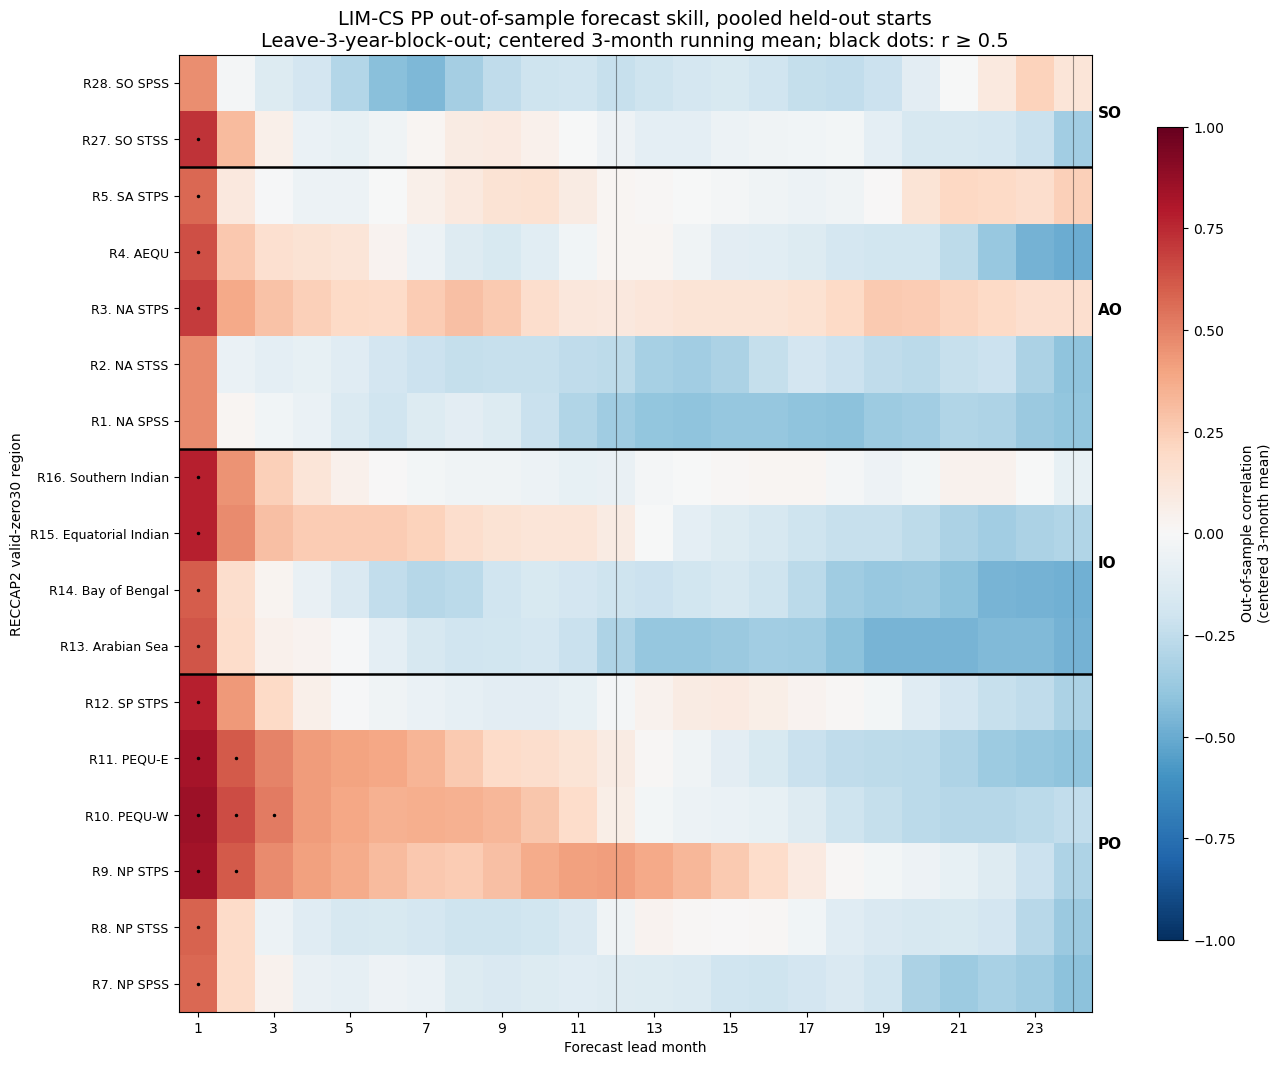

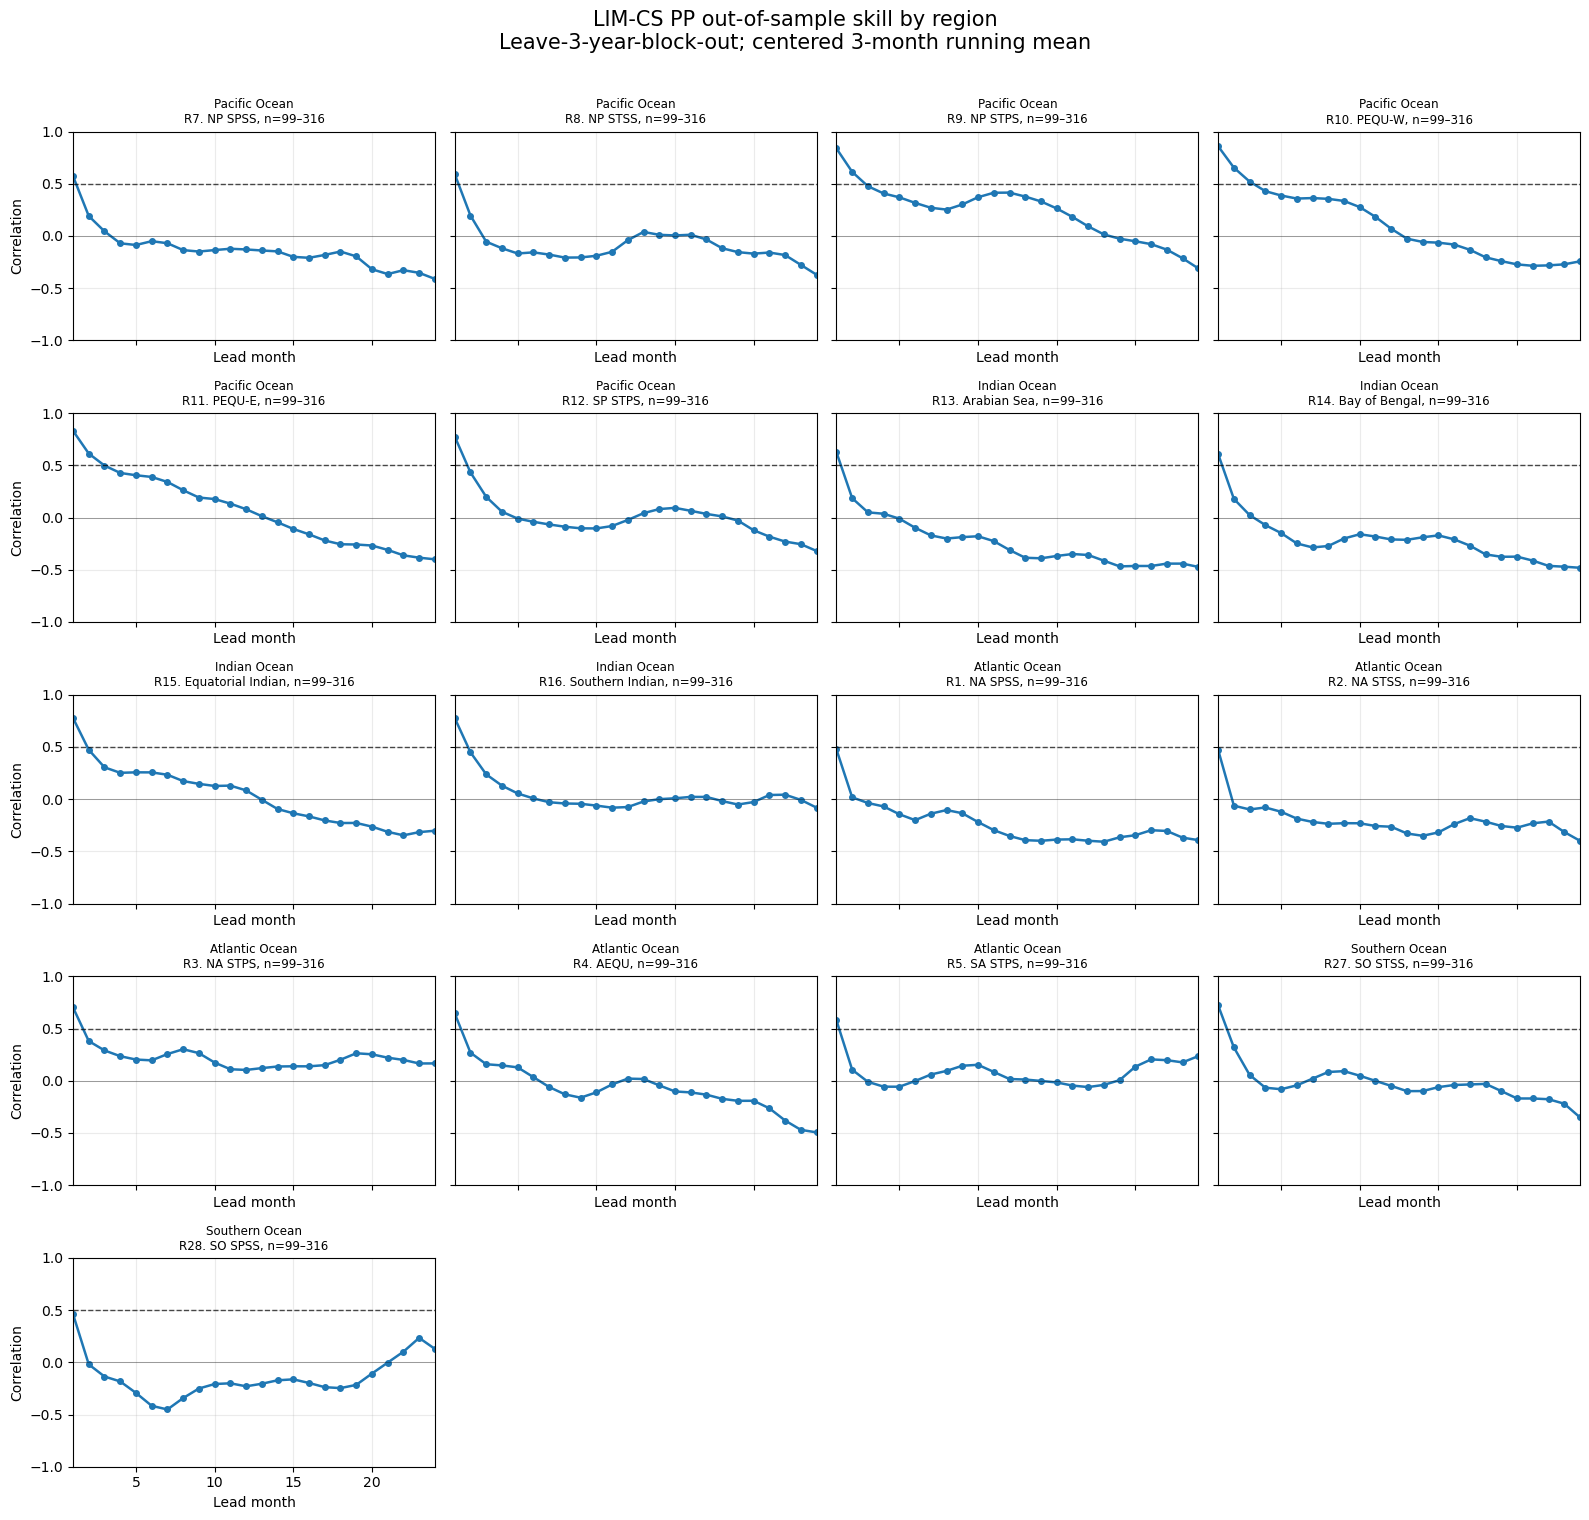

In [5]:
# ============================================================
# 4. Heatmap and regional lines from OOS skill
# ============================================================

with xr.open_dataset(CV_SKILL_FILE) as ds:
    ds_skill = ds.load()

r_pool = ds_skill["PP_correlation_skill"]
n_pool = ds_skill["n_pairs"]
leads = r_pool.lead.values.astype(np.int16)

keep_regions = [
    int(reg) for reg in r_pool.region.values
    if int(reg) not in EXCLUDE_REGIONS
]
region_basin = {int(reg): get_basin_name(ds_skill, reg) for reg in keep_regions}
basin_rank = {name: i for i, name in enumerate(BASIN_ORDER)}
regions_plot = np.array(
    sorted(
        keep_regions,
        key=lambda reg: (basin_rank.get(region_basin[reg], len(BASIN_ORDER)), reg),
    ),
    dtype=np.int16,
)

r_pool = r_pool.sel(region=regions_plot)
n_pool = n_pool.sel(region=regions_plot)
n_region_plot = len(regions_plot)

basin_groups = []
for basin_name in BASIN_ORDER:
    idx = [
        i for i, reg in enumerate(regions_plot)
        if region_basin[int(reg)] == basin_name
    ]
    if idx:
        basin_groups.append({"name": basin_name, "start": min(idx), "end": max(idx)})

basin_centers = [0.5 * (g["start"] + g["end"] + 1) for g in basin_groups]
basin_labels = [BASIN_SHORT.get(g["name"], g["name"]) for g in basin_groups]

fig, ax = plt.subplots(figsize=(14.5, 0.48 * n_region_plot + 3.8))
y_edges = np.arange(n_region_plot + 1)
x_edges = np.arange(leads[0] - 0.5, leads[-1] + 1.5, 1.0)

im = ax.pcolormesh(
    x_edges,
    y_edges,
    r_pool.values,
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    shading="auto",
)

for ireg in range(n_region_plot):
    for ilead, lead in enumerate(leads):
        if np.isfinite(r_pool.values[ireg, ilead]) and r_pool.values[ireg, ilead] >= THRESHOLD:
            ax.plot(lead, ireg + 0.5, "k.", markersize=3)

for group in basin_groups[:-1]:
    ax.axhline(group["end"] + 1, color="k", lw=1.8)

ax_basin = ax.twinx()
ax_basin.set_ylim(0, n_region_plot)
ax_basin.set_yticks(basin_centers)
ax_basin.set_yticklabels(basin_labels, fontsize=11, fontweight="bold")
ax_basin.tick_params(axis="y", length=0, pad=4)
for spine in ax_basin.spines.values():
    spine.set_visible(False)

if leads[-1] >= 12:
    ax.axvline(12, color="k", lw=0.8, alpha=0.4)
if leads[-1] >= 24:
    ax.axvline(24, color="k", lw=0.8, alpha=0.4)

ax.set_xlim(leads[0] - 0.5, leads[-1] + 0.5)
ax.set_ylim(0, n_region_plot)
ax.set_xlabel("Forecast lead month")
ax.set_ylabel("RECCAP2 valid-zero30 region")
ax.set_title(
    "LIM-CS PP out-of-sample forecast skill, pooled held-out starts\n"
    "Leave-3-year-block-out; centered 3-month running mean; "
    f"black dots: r ≥ {THRESHOLD}",
    fontsize=14,
)
ax.set_xticks(np.arange(leads[0], leads[-1] + 1, 2))
ax.set_yticks(np.arange(n_region_plot) + 0.5)
ax.set_yticklabels(
    [get_region_label(ds_skill, reg, short=True) for reg in regions_plot],
    fontsize=9,
)

fig.subplots_adjust(left=0.20, right=0.83, top=0.90, bottom=0.10)
cax = fig.add_axes([0.875, 0.16, 0.018, 0.68])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Out-of-sample correlation\n(centered 3-month mean)")

if SAVE_FIGURES:
    fig.savefig(FIG_HEATMAP, dpi=200, bbox_inches="tight")
plt.show()

ncol = 4
nrow = int(np.ceil(n_region_plot / ncol))
fig, axes = plt.subplots(
    nrow,
    ncol,
    figsize=(16, 3.0 * nrow),
    sharex=True,
    sharey=True,
)
axes = np.asarray(axes).ravel()

for ax, reg in zip(axes, regions_plot):
    r = r_pool.sel(region=reg)
    n = n_pool.sel(region=reg)
    finite_n = n.values[np.isfinite(n.values)]
    n_text = (
        f"n={int(np.nanmin(finite_n))}–{int(np.nanmax(finite_n))}"
        if finite_n.size else "n=NA"
    )

    ax.plot(leads, r.values, marker="o", lw=1.8, ms=4)
    ax.axhline(THRESHOLD, color="k", lw=1.0, ls="--", alpha=0.7)
    ax.axhline(0, color="k", lw=0.6, alpha=0.4)
    ax.set_title(
        f"{region_basin[int(reg)]}\n"
        f"{get_region_label(ds_skill, reg, short=True)}, {n_text}",
        fontsize=8.5,
    )
    ax.set_xlim(leads[0], leads[-1])
    ax.set_ylim(-1, 1)
    ax.grid(alpha=0.25)

for ax in axes[n_region_plot:]:
    ax.axis("off")
for i, ax in enumerate(axes[:n_region_plot]):
    ax.set_xlabel("Lead month")
    if i % ncol == 0:
        ax.set_ylabel("Correlation")

fig.suptitle(
    "LIM-CS PP out-of-sample skill by region\n"
    "Leave-3-year-block-out; centered 3-month running mean",
    fontsize=15,
    y=1.01,
)
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_LINES, dpi=200, bbox_inches="tight")
plt.show()

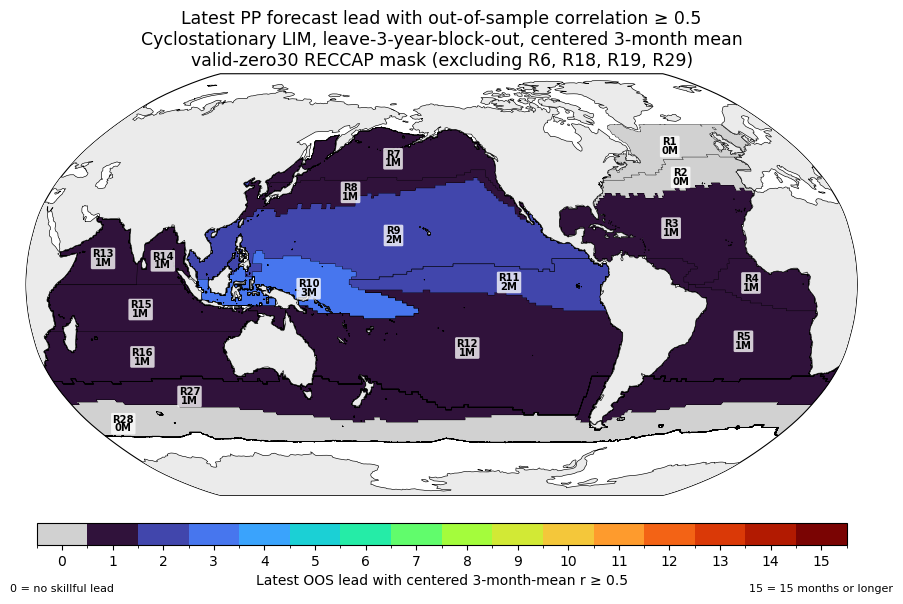

In [6]:
# ============================================================
# 5. Map of latest OOS skillful lead
# ============================================================

import cartopy.crs as ccrs
import cartopy.feature as cfeature

if not VALID_MASK_FILE.exists():
    raise FileNotFoundError(f"Mask file not found:\n{VALID_MASK_FILE}")

with xr.open_dataset(VALID_MASK_FILE) as ds:
    ds_mask = ds.load()
with xr.open_dataset(CV_SKILL_FILE) as ds:
    ds_map_skill = ds.load()

mask = ds_mask["valid_region_mask"]
latest = ds_map_skill["latest_lead_corr_ge_05"]
lat = ds_mask.latitude.values.astype(float)
lon = ds_mask.longitude.values.astype(float)
mask_values = mask.values.astype(np.int16)

mask_plot_full = mask_values.copy()
for reg_ex in EXCLUDE_REGIONS:
    mask_plot_full[mask_plot_full == reg_ex] = 0

mask_region_set = set(np.unique(mask_plot_full[mask_plot_full > 0]).astype(int))
regions_to_plot = [
    int(reg) for reg in latest.region.values
    if int(reg) not in EXCLUDE_REGIONS and int(reg) in mask_region_set
]
latest_plot = latest.sel(region=regions_to_plot)

lead_map = np.full(mask_values.shape, np.nan, dtype=np.float32)
for reg in latest_plot.region.values:
    reg = int(reg)
    lead_map[mask_plot_full == reg] = float(latest_plot.sel(region=reg).values)
lead_map = np.where(mask_plot_full > 0, lead_map, np.nan)

lat_plot = lat[::PLOT_STRIDE]
lon_plot = lon[::PLOT_STRIDE]
lead_plot = lead_map[::PLOT_STRIDE, ::PLOT_STRIDE]
mask_plot = mask_plot_full[::PLOT_STRIDE, ::PLOT_STRIDE].astype(float)
lead_cyc, lon_cyc = add_cyclic_manual(lead_plot, lon_plot)
mask_cyc, _ = add_cyclic_manual(mask_plot, lon_plot)

remaining_regions = np.unique(mask_plot_full[mask_plot_full > 0])
boundary_levels = np.arange(0.5, int(np.nanmax(remaining_regions)) + 1.5, 1.0)

lead_cyc_plot = np.where(
    np.isfinite(lead_cyc),
    np.minimum(lead_cyc, DISPLAY_MAX_LEAD),
    np.nan,
)
bounds = np.arange(-0.5, DISPLAY_MAX_LEAD + 1.5, 1.0)
try:
    base = plt.get_cmap("turbo", DISPLAY_MAX_LEAD)
except ValueError:
    base = plt.get_cmap("plasma", DISPLAY_MAX_LEAD)
colors = [(0.82, 0.82, 0.82, 1.0)] + [base(i) for i in range(DISPLAY_MAX_LEAD)]
cmap = ListedColormap(colors)
cmap.set_bad((1, 1, 1, 0))
norm = BoundaryNorm(bounds, cmap.N)

fig = plt.figure(figsize=(13.5, 6.2))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=CENTRAL_LONGITUDE))
im = ax.pcolormesh(
    lon_cyc,
    lat_plot,
    lead_cyc_plot,
    cmap=cmap,
    norm=norm,
    shading="auto",
    transform=ccrs.PlateCarree(),
)
ax.contour(
    lon_cyc,
    lat_plot,
    mask_cyc,
    levels=boundary_levels,
    colors="k",
    linewidths=0.30,
    transform=ccrs.PlateCarree(),
)
ax.add_feature(cfeature.LAND, facecolor="0.92", edgecolor="none", zorder=3)
ax.coastlines(linewidth=0.45, zorder=4)
ax.set_global()
ax.set_title(
    "Latest PP forecast lead with out-of-sample correlation ≥ 0.5\n"
    "Cyclostationary LIM, leave-3-year-block-out, centered 3-month mean\n"
    "valid-zero30 RECCAP mask (excluding R6, R18, R19, R29)",
    fontsize=12.5,
)

for reg in latest_plot.region.values:
    reg = int(reg)
    region_mask = mask_plot_full == reg
    if not np.any(region_mask):
        continue
    lon_c, lat_c = weighted_centroid(lon, lat, region_mask)
    if not (np.isfinite(lon_c) and np.isfinite(lat_c)):
        continue
    value = int(latest_plot.sel(region=reg).values)
    ax.text(
        lon_to_180(lon_c),
        lat_c,
        f"R{reg}\n{value}M",
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=7.2,
        fontweight="bold",
        linespacing=0.85,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.78, boxstyle="round,pad=0.14"),
        zorder=5,
    )

fig.subplots_adjust(left=0.03, right=0.97, top=0.84, bottom=0.16)
cax = fig.add_axes([0.20, 0.08, 0.60, 0.035])
cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    ticks=np.arange(0, DISPLAY_MAX_LEAD + 1, 1),
    boundaries=bounds,
)
cbar.set_label("Latest OOS lead with centered 3-month-mean r ≥ 0.5")
cbar.ax.text(
    0,
    -1.8,
    "0 = no skillful lead",
    ha="center",
    va="top",
    transform=cbar.ax.get_xaxis_transform(),
    fontsize=8,
)
cbar.ax.text(
    DISPLAY_MAX_LEAD,
    -1.8,
    f"{DISPLAY_MAX_LEAD} = {DISPLAY_MAX_LEAD} months or longer",
    ha="center",
    va="top",
    transform=cbar.ax.get_xaxis_transform(),
    fontsize=8,
)

if SAVE_FIGURES:
    fig.savefig(MAP_FIG, dpi=200, bbox_inches="tight")
plt.show()